In [2]:
from PIL import Image, ImageDraw
import pandas as pd
import os
import numpy as np

In [3]:
vehicles = pd.read_csv('C:\\Users\\rober\\OneDrive\\Desktop\\CS7150\\CS7180-Final\\data\\annotations\\vehicles.csv')
bboxes   = pd.read_csv('C:\\Users\\rober\\OneDrive\\Desktop\\CS7150\\CS7180-Final\\data\\annotations\\bboxes.csv')

bboxes.loc[:, 'x'] = (bboxes.x2 + bboxes.x1)/2
bboxes.loc[:, 'y'] = (bboxes.y2 + bboxes.y1)/2

# Vehicle speed by video
I wanted to see which video contained the highest average speed and found that the video 1 had an average speed of 20km/h. Video 2 had the slowest recorded speeds at and average of 10km/h. 

**Why does this matter?** Speed impacts reaction time. The faster the vihecle the shorter the respond time. We may want to adjust our sensitivity when approaching at higher rate of speed.

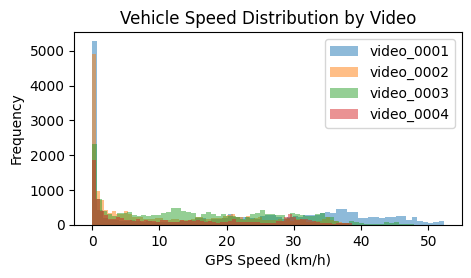

In [4]:
vehicles.groupby('video').GPS_speed.plot.hist(
    bins=65, alpha=0.5, legend=True, 
    title='Vehicle Speed Distribution by Video', 
    xlabel='GPS Speed (km/h)', ylabel='Frequency',
    figsize=(5, 2.5));

## Comparison of Vehicle Speed and Pedestrian Density

We plotted heat maps of vehicle speed and pedestrian density along the latitude and longitude axes to identify where pedestrians cross. The results show a clear divide between pedestrian-heavy areas and long stretches of road where the vehicle travels at higher speeds.

**Why this matters?** Heavely populated locations may prove to be difficult for our model to predict pedestrian crossing. Also, poorly populated streaches of road may be have pedestrians that are marked by a boundery box but are too far away for us to need to predict.

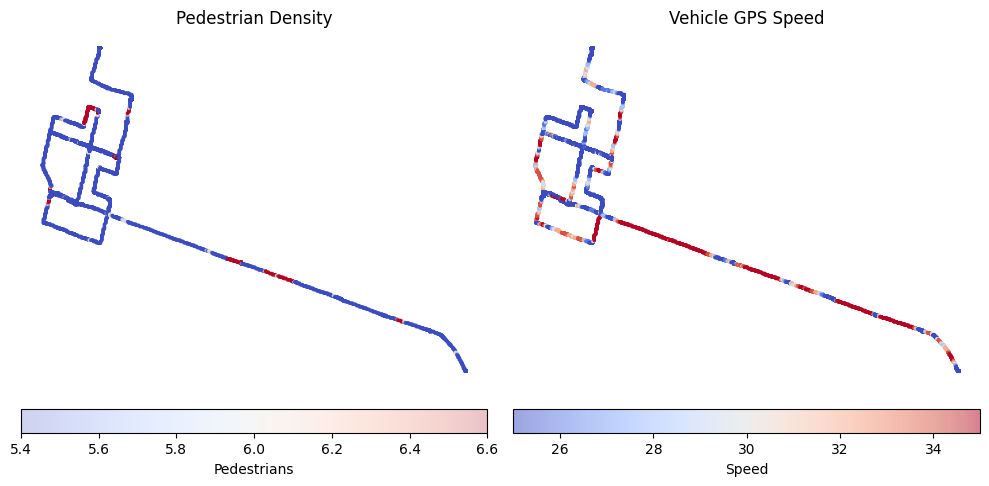

In [5]:
import matplotlib.pyplot as plt

population = vehicles.merge(bboxes.loc[bboxes.content=='pedestrian', ['frame','id','y1','y2']], on='frame', how='left')
population['bbox_height'] = (population.y1 - population.y2).abs().fillna(0)  # Pedestrian height as a proxy for distance
population = population.groupby(['latitude','longitude'], as_index=False).agg(
    Pedestrians=('id', 'nunique'), 
    Speed=('OBD_speed', 'mean'), 
    BboxHeight=('bbox_height', 'mean')).round(4)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

sc1 = population.plot.scatter(
    x='latitude', y='longitude', c='Pedestrians', 
    colormap='coolwarm', s=2, alpha=0.25, vmin=6,vmax=6,
    ax=ax1, colorbar=False
)
ax1.set_title('Pedestrian Density')
ax1.set_axis_off()

sc2 = population.round(4).plot.scatter(
    x='latitude', y='longitude', c='Speed', 
    colormap='coolwarm', s=2, alpha=0.5, vmin=25, vmax=35,
    ax=ax2, colorbar=False
)
ax2.set_title('Vehicle GPS Speed')
ax2.set_axis_off()

# 'pad' adds space between the chart and the bar
fig.colorbar(sc1.collections[0], ax=ax1, orientation='horizontal', pad=0.05, label='Pedestrians')
fig.colorbar(sc2.collections[0], ax=ax2, orientation='horizontal', pad=0.05, label='Speed')

plt.tight_layout()
plt.show()

# Proximity of pedestrians to vehicle
We assume that bounding boxes closer to the vehicle are taller due to the camera's perspective. We also assume that at higher speeds the pedestrians wil be far way from the center of the camera. The scatterplot below shows that the correlation between speed and bounding box heights are invesly correlated.

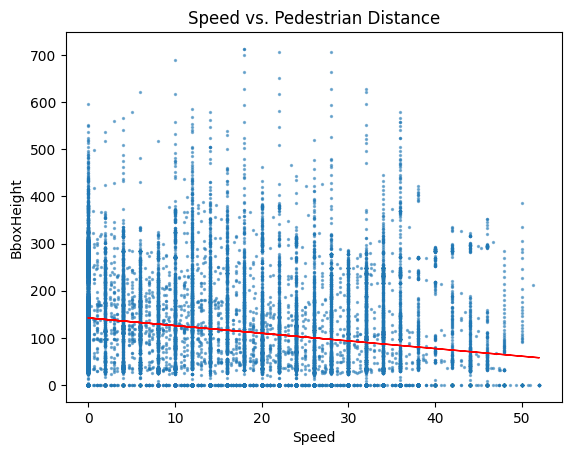

In [6]:
ax = population.plot.scatter(x='Speed', y='BboxHeight', s=2, alpha=0.5, colorbar=False, title='Speed vs. Pedestrian Distance')
x = population['Speed']
y = population['BboxHeight']
m, b = np.polyfit(x, y, 1)
ax.plot(x, m*x + b, color='red', linewidth=1)


# Exploring pedestrian behavior
The annotated data includes a set of behaviors including "looking", "gesturing", and "crossing." We can study these gestures to know when the pedestrian is aware of oncomming traffic. The GIF below has the annotated behaviors for each bounding box in the frames. 

**Why this mattes?** I'm assuming that pedestrians who look have the intention of crossing and therefore signals such as these may help predict when the intent. 

In [7]:
video = 'video_0003'# 'video_0002'
start_frame = 9700 #7700
end_frame = 10000 #7900  
frames_list = []

for frame_num in range(start_frame, end_frame + 1):
    frame_str = f"{frame_num:05d}"
    path = f"C:\\Users\\rober\\OneDrive\\Desktop\\CS7150\\CS7180-Final\\data/images/set01/{video}/{frame_str}.png"
    
    try:
        img = Image.open(path).convert("RGB")
        draw = ImageDraw.Draw(img)
        boxes = bboxes.loc[(bboxes.video == video) & (bboxes.frame == frame_num), 
                           ['x1', 'y1', 'x2', 'y2', 'look', 'cross', 'gesture']].values
        
        for x1, y1, x2, y2, look, cross, gesture in boxes:
            draw.rectangle([x1, y1, x2, y2], outline="red", width=2)
            label = "" + ("Gesture" if gesture == 1 else ("Looking" if look == 1 else ("Crossing" if cross == 1 else "")))
            draw.text((x1, y1), label, fill="white", background="red")

        frames_list.append(img)
    except FileNotFoundError:
        print(f"Skipping missing frame: {frame_str}")

if frames_list:
    frames_list[0].save(
        'pedestrian_detection.gif',
        save_all=True,
        append_images=frames_list[1:],
        duration=60,
        loop=0
    )
    print("GIF created successfully.")

GIF created successfully.


![Pedestrian Detection](pedestrian_detection.gif)

# Traffic light states
The bounding boxes also contain traffic light signals (state). The states are categorical values labeled 0-3. Only one traffic light was labeled 0. We assume pedestrians are crossing when the light is red. I want to validate this assumption so I collected the frames at various states and compare to translate them to red, yellow, green.

**Why this matters?** Traffic signals are widely followed by motorists. Pedestrians anticipate motorist behavior based on traffic lights. Therefore, the signals may provide our model with strong predictive power.

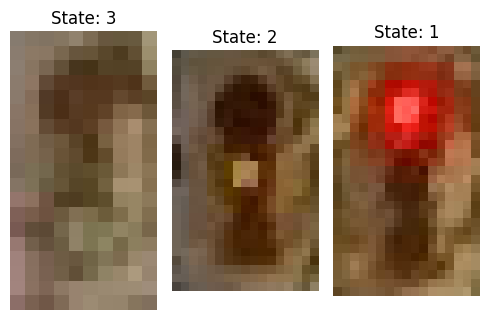

In [44]:
import matplotlib.pyplot as plt
from PIL import Image

# 1. Define your file paths
paths = [
    "C:\\Users\\rober\\OneDrive\\Desktop\\CS7150\\CS7180-Final\\data/images/set01/video_0003/09290.png",
    "C:\\Users\\rober\\OneDrive\\Desktop\\CS7150\\CS7180-Final\\data/images/set01/video_0003/09410.png",
    "C:\\Users\\rober\\OneDrive\\Desktop\\CS7150\\CS7180-Final\\data/images/set01/video_0003/10196.png"
]

crops =[[884.58, 732.54, 894.75, 751.9],
 [792.1, 690.63, 809.32, 719.21],
 [754.01, 692.36, 771.23, 720.94]]
states = [3, 2, 1]
# 2. Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(5, 5))

# 3. Loop through the paths and axes to plot
for ax, path, crop, state in zip(axes, paths, crops, states):
    img = Image.open(path).crop(crop)
    ax.imshow(img)
    ax.axis('off')  # Hide ticks and labels
    ax.set_title(f"State: {state}") # Optional: set title to filename

plt.tight_layout()
plt.show()

# Finding

We don't have any examples of pedestrians crossing when the traffic light is yellow. Likely because pedestrians fear a motorist trying to beat the red-light may hit them if they cross. Also, we only have 175 instances of yellow lights to while it's likely a low occurance, we do not have enough examples to tell definatively confirm. In 23% of red and green lights a pedestrian is crossing.

3. means Green.
2. means yellow.
1. means red


In [52]:
jwalkers = bboxes.groupby(['video', 'frame'], as_index=False).agg(Light=('state', 'max'), Crossing=('cross', 'max'), Gesture=('gesture', 'max'))
pd.crosstab(jwalkers.Light, jwalkers.Crossing)

Crossing,0.0,1.0
Light,,
1.0,3684,858
2.0,175,0
3.0,1924,462
